In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/teachingratings.csv")

In [21]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   minority         463 non-null    object 
 1   age              463 non-null    int64  
 2   gender           463 non-null    object 
 3   credits          463 non-null    object 
 4   beauty           463 non-null    float64
 5   eval             463 non-null    float64
 6   division         463 non-null    object 
 7   native           463 non-null    object 
 8   tenure           463 non-null    object 
 9   students         463 non-null    int64  
 10  allstudents      463 non-null    int64  
 11  prof             463 non-null    int64  
 12  PrimaryLast      463 non-null    int64  
 13  vismin           463 non-null    int64  
 14  female           463 non-null    int64  
 15  single_credit    463 non-null    int64  
 16  upper_division   463 non-null    int64  
 17  En

In [23]:
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
              age        beauty        eval    students  allstudents  \
count  463.000000  4.630000e+02  463.000000  463.000000   463.000000   
mean    48.365011  6.271140e-08    3.998272   36.624190    55.177106   
std      9.802742  7.886477e-01    0.554866   45.018481    75.072800   
min     29.000000 -1.450494e+00    2.100000    5.000000     8.000000   
25%     42.000000 -6.562689e-01    3.600000   15.000000    19.000000   
50%     48.000000 -6.801430e-02    4.000000   23.000000    29.000000   
75%     57.000000  5.456024e-01    4.400000   40.000000    60.000000   
max     73.000000  1.970023e+00    5.000000  380.000000   581.000000   

             prof  PrimaryLast      vismin      female  single_credit  \
count  463.000000   463.000000  463.000000  463.000000     463.000000   
mean    45.434125     0.203024    0.138229    0.421166       0.058315   
std     27.508902     0.402685    0.345513    0.494280       0.234592   
min      1.000000     0.000000    

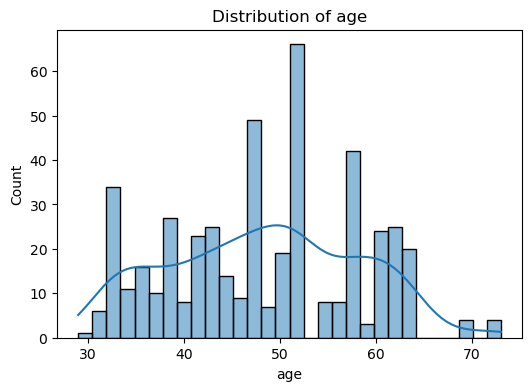

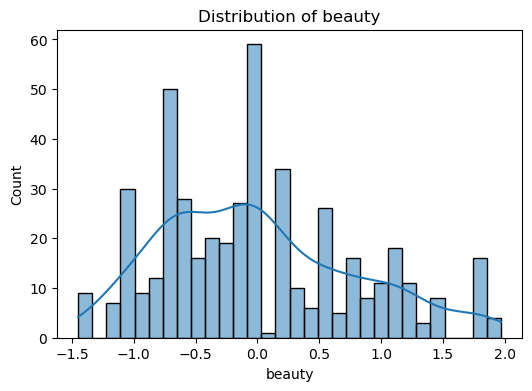

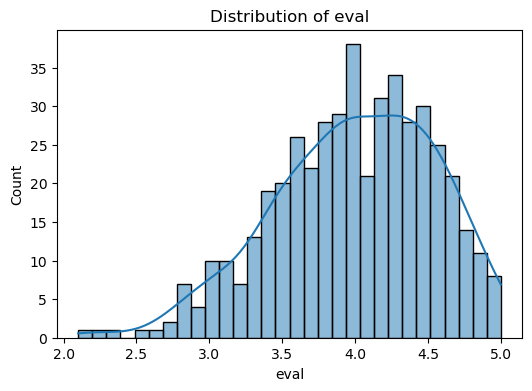

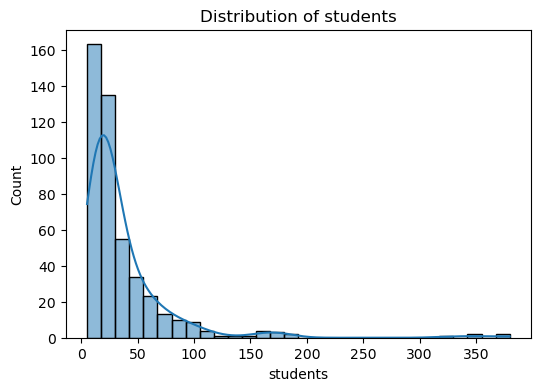

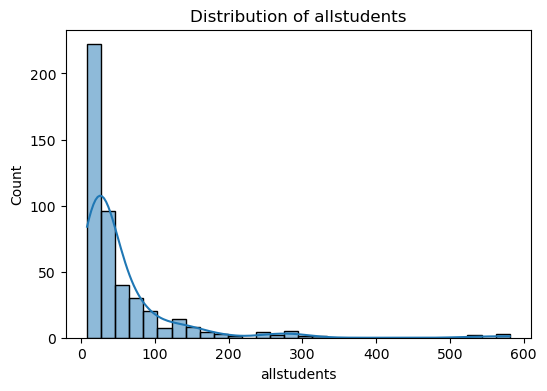

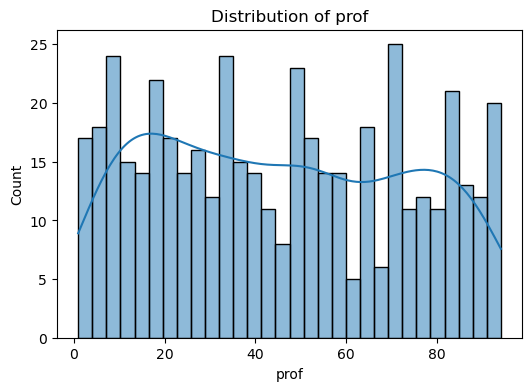

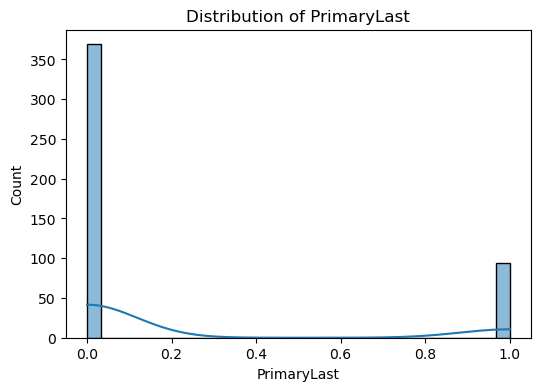

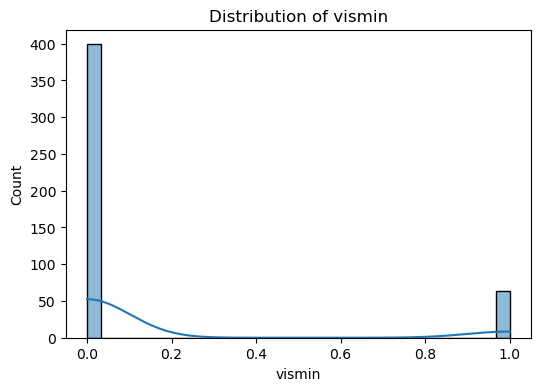

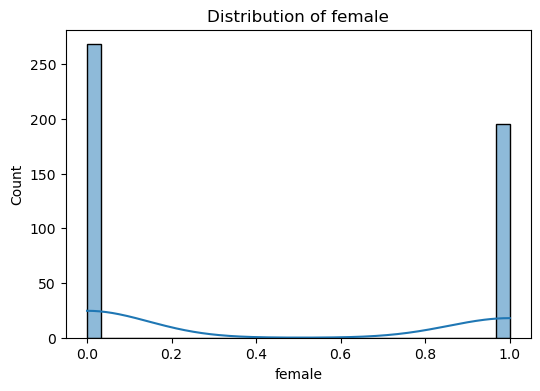

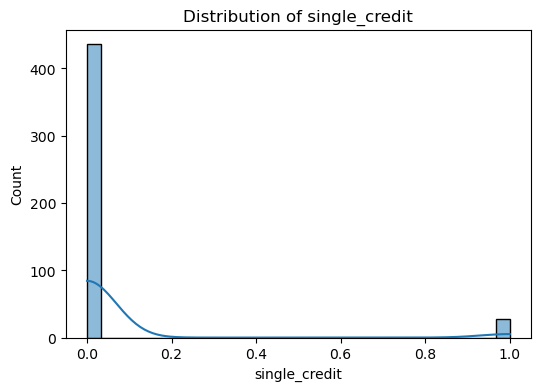

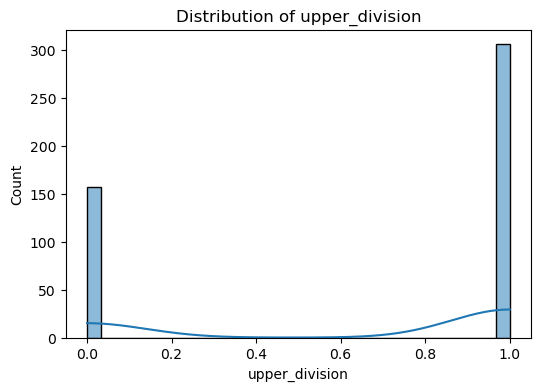

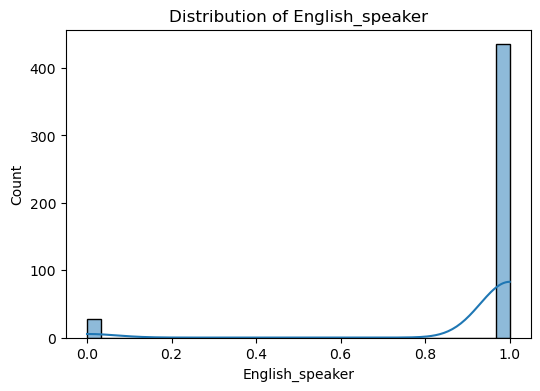

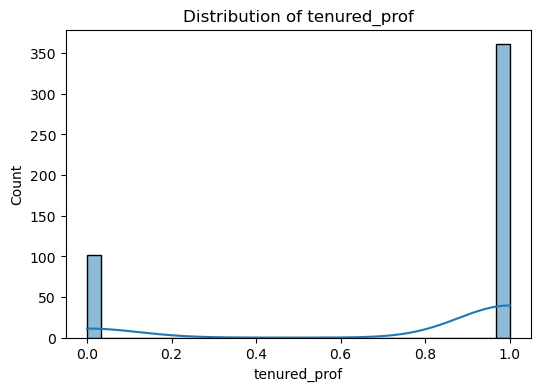

In [51]:
for column in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[column], bins=30, kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

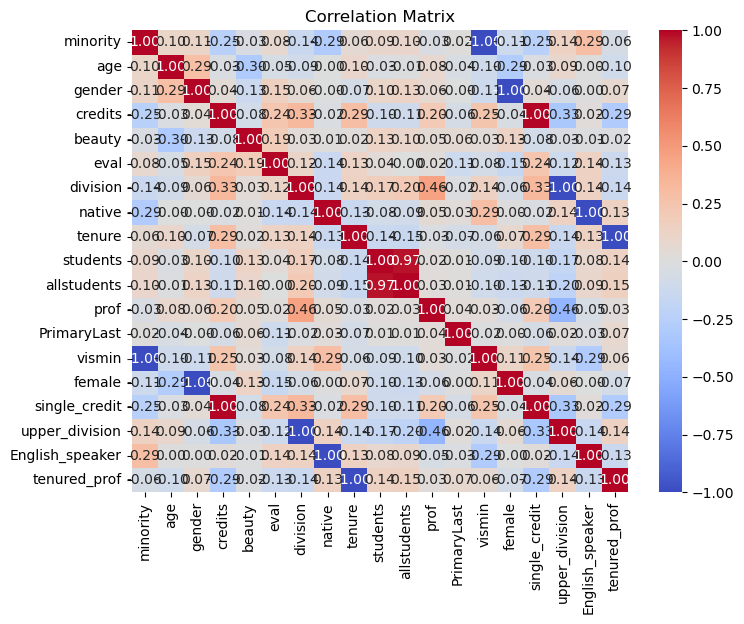

In [59]:
plt.figure(figsize=(8,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [89]:
from scipy import stats
import pandas as pd

In [91]:
df = df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/teachingratings.csv")

In [99]:
print(df.columns)

Index(['minority', 'age', 'gender', 'credits', 'beauty', 'eval', 'division',
       'native', 'tenure', 'students', 'allstudents', 'prof', 'PrimaryLast',
       'vismin', 'female', 'single_credit', 'upper_division',
       'English_speaker', 'tenured_prof'],
      dtype='object')


In [161]:
ttest_result = stats.ttest_ind(df['age'], df['eval'], nan_policy='omit')
print("\nT-test result:", ttest_result)


T-test result: TtestResult(statistic=97.23123869996856, pvalue=0.0, df=924.0)


In [165]:
anova_result = stats.f_oneway(df['age'], df['eval'], df['beauty'])
print("\nANOVA result:", anova_result)


ANOVA result: F_onewayResult(statistic=10316.109246325304, pvalue=0.0)


In [169]:
pearson_corr, p_value = stats.pearsonr(df['age'], df['eval'])
print("\nPearson correlation coefficient:", pearson_corr)
print("P-value:", p_value)


Pearson correlation coefficient: -0.05169619363177701
P-value: 0.26695379096201555


In [173]:
import statsmodels.api as sm

In [179]:
X = sm.add_constant(df[['age']])
Y = df['eval']

In [181]:
model = sm.OLS(Y, X).fit()

In [183]:
print("\nRegression Analysis Summary:")
print(model.summary())


Regression Analysis Summary:
                            OLS Regression Results                            
Dep. Variable:                   eval   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.235
Date:                Sat, 03 May 2025   Prob (F-statistic):              0.267
Time:                        18:56:22   Log-Likelihood:                -383.13
No. Observations:                 463   AIC:                             770.3
Df Residuals:                     461   BIC:                             778.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1398 